# 5. Modelo Híbrido

Este notebook combina las señales de los **cuatro modelos** entrenados en los notebooks anteriores mediante una fusión ponderada de scores:

$$\text{score}(u, i) = w_1 \cdot \hat{s}_{\text{pop}}(i) + w_2 \cdot \hat{s}_{\text{cb}}(u,i) + w_3 \cdot \hat{s}_{\text{cf}}(u,i) + w_4 \cdot \hat{s}_{\text{pmlp}}(u,i)$$

donde cada $\hat{s}$ es el score min-max normalizado a $[0, 1]$ del modelo correspondiente.

### Ciclo de vida del usuario (contexto de producción)

| Etapa | Condición | Modelos activos |
|-------|-----------|----------------|
| Nuevo | 0 ratings, tiene personalidad | PMLP |
| Semilla | ≥1 rating positivo | + Content-Based |
| Activo | ≥10 ratings | + CF |
| **Completo** | **≥15 ratings** | **Hybrid (los 4)** |

En producción se usaría una estrategia **switching** que active modelos según la etapa. Aquí evaluamos **solo el escenario Completo** (≥15 ratings) con weighted score fusion.

### Protocolo

- **Benchmark** (full-catalog): 6 métricas estándar (Precision, Recall, NDCG, Diversity, Novelty, Coverage).
- **Survey** (sampled LOO, 1+99): HR@K y NDCG@K. Solo usuarios con ≥15 ratings.
- **Tuning**: Random search sobre inner-validation del benchmark, seleccionando por NDCG@10.

In [64]:
import json
import pickle
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from tabulate import tabulate

sys.path.insert(0, str(Path.cwd().parent.parent))
import ml.config as cfg
from ml.evaluation import notebook_utils as nu
from ml.evaluation.metrics import ndcg_at_k, hit_rate_at_k
from ml.evaluation.splits import movielens_split, survey_split_sampled
from ml.models.base import BaseRecommender
from ml.models.popularity import PopularityRecommender
from ml.models.content_based import ContentBasedRecommender
from ml.models.lightgcn import LightGCN
from ml.models.bprmf import BPRMF
from ml.models.surprise_svd import SurpriseSVD, SurpriseSVDpp
from ml.models.personality import PersonalityMLPRecommender

K = 10
SAVED_DIR = Path('..') / 'models' / 'saved'
print(f'K={K}  SAVED_DIR={SAVED_DIR}')


K=10  SAVED_DIR=../models/saved


## 1. Carga de datos y splits

In [65]:
cosine_sim = cfg.load_cosine_sim()
popularity = cfg.load_popularity()
N_ITEMS = cfg.catalog_size()

train, test = movielens_split(cfg.RATINGS_PATH)
print(f'Benchmark  train={len(train):,}  test={len(test):,}  N_ITEMS={N_ITEMS}')

# Survey folds — filtrar a usuarios con ≥15 ratings
sv_folds_all = survey_split_sampled(
    nu.RATINGS_SURVEY_PATH, cfg.MOVIES_PATH, n_negatives=99, seed=42,
)
MIN_RATINGS = 15
sv_folds = []
for tr, te, cands in sv_folds_all:
    uid = int(te['user_id'].iloc[0])
    n_ratings = len(tr[tr['user_id'] == uid])
    if n_ratings >= MIN_RATINGS:
        sv_folds.append((tr, te, cands))
print(f'Survey folds (≥{MIN_RATINGS} ratings): {len(sv_folds)} / {len(sv_folds_all)}')

Benchmark  train=797,809  test=108,298  N_ITEMS=3830
Survey folds (≥15 ratings): 86 / 118


## 2. Carga de modelos guardados

Se cargan los 4 modelos persistidos por los notebooks 1-4 y se ajustan sobre el train del benchmark.

In [66]:
# 1. Popularity
pop_model = PopularityRecommender.load(SAVED_DIR / 'popularity.pkl')
pop_model.fit(train)
print('✓ Popularity')

# 2. Content-Based
with open(SAVED_DIR / 'content_based_meta.json') as f:
    cb_meta = json.load(f)
cb_model = ContentBasedRecommender(
    cosine_sim_path=cfg.COSINE_SIM_PATH, movies_path=cfg.MOVIES_PATH,
    cosine_sim=cosine_sim, **cb_meta['hyperparameters'],
)
cb_model.fit(train)
print('✓ Content-Based')

# 3. CF
with open(SAVED_DIR / 'collaborative_meta.json') as f:
    cf_meta = json.load(f)
cf_name = cf_meta['model']
if cf_name == 'LightGCN':
    cf_model = LightGCN.load(SAVED_DIR / 'collaborative.npz')
else:
    cf_model = pickle.load(open(SAVED_DIR / 'collaborative.pkl', 'rb'))
cf_model._seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    cf_model._seen.setdefault(int(uid), set()).add(int(mid))
print(f'✓ {cf_name}')

# 4. PMLP — cargar modelo + inyectar personalidades del benchmark
with open(SAVED_DIR / 'pmlp_sv.pkl', 'rb') as f:
    pmlp_model = pickle.load(f)
ratings_raw = pd.read_parquet(cfg.RATINGS_PATH)
pers_bench = cfg.derive_personalities(
    ratings_raw[['user_id', 'movie_id', 'rating']], pd.read_csv(cfg.MOVIES_PATH),
)
pmlp_model.set_personalities(pers_bench)
pmlp_model._user_seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    pmlp_model._user_seen.setdefault(int(uid), set()).add(int(mid))
print(f'✓ PMLP ({len(pmlp_model._traits)} usuarios con personalidad)')

models = {
    'Popularity': pop_model,
    'Content-Based': cb_model,
    cf_name: cf_model,
    'PMLP': pmlp_model,
}
model_list = list(models.values())
print(f'\n{len(models)} modelos cargados: {list(models.keys())}')


✓ Popularity
✓ Content-Based
✓ LightGCN
✓ PMLP (6000 usuarios con personalidad)

4 modelos cargados: ['Popularity', 'Content-Based', 'LightGCN', 'PMLP']


## 3. HybridRankFusionRecommender

Clase que combina los **rankings** (no scores) de múltiples modelos usando Reciprocal Rank Fusion (RRF):

$$\text{score}(i) = \sum_m \frac{w_m}{k + \text{rank}_m(i)}$$

donde $k=60$ es una constante de suavizado. Esto evita el sesgo de popularidad que ocurre con score fusion, porque no importa la magnitud de los scores — solo el orden relativo.

In [67]:
RRF_K = 60  # constante de suavizado estándar

class HybridRankFusionRecommender(BaseRecommender):
    """Reciprocal Rank Fusion over multiple recommenders.
    
    fit() only updates seen maps for lightweight models (Popularity,
    Content-Based). CF and PMLP keep their pre-trained weights and
    only get their seen/user_seen maps updated.
    """
    def __init__(self, models: list, weights: list[float]):
        self._models = models
        self._weights = np.array(weights, dtype=np.float64)
        self._user_seen: dict[int, set[int]] = {}

    def set_weights(self, weights):
        self._weights = np.array(weights, dtype=np.float64)

    def fit(self, ratings: pd.DataFrame):
        seen = {}
        for uid, mid in zip(ratings['user_id'].values, ratings['movie_idx'].values):
            seen.setdefault(int(uid), set()).add(int(mid))
        self._user_seen = seen
        for m in self._models:
            if isinstance(m, (PopularityRecommender, ContentBasedRecommender)):
                m.fit(ratings)
            elif hasattr(m, '_seen'):
                m._seen = seen
            elif hasattr(m, '_user_seen'):
                m._user_seen = seen

    def score_all(self, user_id: int) -> np.ndarray | None:
        max_len = 0
        for m in self._models:
            s = m.score_all(user_id)
            if s is not None:
                max_len = max(max_len, len(s))
        if max_len == 0:
            return None
        rank_scores = np.zeros(max_len, dtype=np.float64)
        for m, w in zip(self._models, self._weights):
            s = m.score_all(user_id)
            if s is None:
                continue
            ranks = np.empty(len(s), dtype=np.float64)
            ranks[np.argsort(-s)] = np.arange(1, len(s) + 1)
            rrf = w / (RRF_K + ranks)
            rank_scores[:len(rrf)] += rrf
        return rank_scores.astype(np.float32)

    def recommend(self, user_id: int, n: int = 10, exclude: set[int] | None = None) -> list[int]:
        scores = self.score_all(user_id)
        if scores is None:
            return []
        seen = set(self._user_seen.get(user_id, set()))
        if exclude:
            seen |= exclude
        scores = scores.copy()
        for idx in seen:
            if 0 <= idx < len(scores):
                scores[idx] = -np.inf
        return np.argsort(-scores)[:n].tolist()

print('HybridRankFusionRecommender definido')


HybridRankFusionRecommender definido


## 4. Búsqueda de pesos óptimos

Se evaluaron 100 combinaciones de pesos: **15 combinaciones estratégicas** (diseñadas para dar peso alto a LightGCN, que es el mejor modelo individual) + **85 combinaciones aleatorias**.

**Objetivo compuesto**:

$\text{score} = 0.80 \times \text{NDCG@K} + 0.10 \times \text{Coverage} + 0.10 \times \text{Novelty}$

El peso dominante de NDCG (80%) asegura que el ranking sea la prioridad, mientras que el 20% restante incentiva la exploración del catálogo. Las combinaciones estratégicas garantizan que se explore la región del espacio de pesos donde CF tiene 40–80% del peso total.

In [ ]:
# Inner train/val split for tuning
rng = np.random.default_rng(42)
shuf = train.sample(frac=1, random_state=42).reset_index(drop=True)
cut = int(len(shuf) * 0.9)
inner_train = shuf.iloc[:cut].reset_index(drop=True)
inner_val = shuf.iloc[cut:].reset_index(drop=True)
inner_val_pos = inner_val[inner_val['rating'] >= 4.0]
val_users = rng.choice(inner_val_pos['user_id'].unique(), size=min(500, inner_val_pos['user_id'].nunique()), replace=False)
val_relevant = inner_val_pos[inner_val_pos['user_id'].isin(val_users)].groupby('user_id')['movie_idx'].apply(set).to_dict()
print(f'Inner split: train={len(inner_train):,}  val_users={len(val_users)}')

# Fit lightweight models on inner_train
pop_model.fit(inner_train)
cb_model.fit(inner_train)
cf_model._seen = {}
for uid, mid in zip(inner_train['user_id'].values, inner_train['movie_idx'].values):
    cf_model._seen.setdefault(int(uid), set()).add(int(mid))
pmlp_model._user_seen = {}
for uid, mid in zip(inner_train['user_id'].values, inner_train['movie_idx'].values):
    pmlp_model._user_seen.setdefault(int(uid), set()).add(int(mid))

model_list = list(models.values())
hybrid = HybridRankFusionRecommender(model_list, [0.25]*4)
hybrid._user_seen = {}
for uid, mid in zip(inner_train['user_id'].values, inner_train['movie_idx'].values):
    hybrid._user_seen.setdefault(int(uid), set()).add(int(mid))

from ml.evaluation.metrics import ndcg_at_k as _ndcg, coverage as _coverage, novelty_at_k as _novelty

# Objetivo compuesto: 80% NDCG + 10% Coverage + 10% Novelty
NDCG_WEIGHT = 0.80
COV_WEIGHT = 0.10
NOV_WEIGHT = 0.10

def evaluate_weights(w):
    hybrid.set_weights(w)
    ndcgs, all_recs, novs = [], [], []
    for uid, rel in val_relevant.items():
        recs = hybrid.recommend(int(uid), n=K)
        if recs:
            ndcgs.append(_ndcg(recs, rel, K))
            all_recs.append(recs)
            novs.append(_novelty(recs, popularity, K))
    avg_ndcg = float(np.mean(ndcgs)) if ndcgs else 0.0
    cov = _coverage(all_recs, N_ITEMS) if all_recs else 0.0
    avg_nov = float(np.mean(novs)) if novs else 0.0
    composite = NDCG_WEIGHT * avg_ndcg + COV_WEIGHT * cov + NOV_WEIGHT * avg_nov
    return {'ndcg': avg_ndcg, 'coverage': cov, 'novelty': avg_nov, 'composite': composite}

# Combinaciones estratégicas: dar peso alto a CF (LightGCN) que es el mejor modelo
# Orden de pesos: [pop, cb, cf, pmlp]
strategic_weights = [
    [0.05, 0.15, 0.60, 0.20],  
    [0.05, 0.20, 0.55, 0.20],  
    [0.05, 0.10, 0.65, 0.20],  
    [0.10, 0.15, 0.50, 0.25],  
    [0.05, 0.25, 0.45, 0.25],  
    [0.00, 0.20, 0.60, 0.20],  
    [0.00, 0.15, 0.70, 0.15],  
    [0.05, 0.10, 0.70, 0.15],  
    [0.10, 0.20, 0.40, 0.30],  
    [0.05, 0.30, 0.40, 0.25],  
    [0.00, 0.10, 0.80, 0.10],  
    [0.00, 0.00, 1.00, 0.00],  
    [0.05, 0.20, 0.50, 0.25],  
    [0.00, 0.25, 0.50, 0.25],  
    [0.10, 0.10, 0.55, 0.25], 
]

# Agregar 85 combinaciones aleatorias 
N_RANDOM = 85
all_weight_combos = [np.array(w) for w in strategic_weights]
for _ in range(N_RANDOM):
    all_weight_combos.append(rng.dirichlet([1, 1, 1, 1]))

N_TRIALS = len(all_weight_combos)
trials = []
t0 = time.time()
for trial_i, w in enumerate(all_weight_combos):
    w = np.array(w)
    w = w / w.sum()  # normalize
    result = evaluate_weights(w)
    trials.append({'w_pop': w[0], 'w_cb': w[1], 'w_cf': w[2], 'w_pmlp': w[3], **result})
    if (trial_i + 1) % 25 == 0:
        print(f'  trial {trial_i+1}/{N_TRIALS}  elapsed={time.time()-t0:.0f}s')

trials_df = pd.DataFrame(trials).sort_values('composite', ascending=False).reset_index(drop=True)
print(f'\nSearch completado en {time.time()-t0:.0f}s')
print(f'\nTop-10 trials (por score compuesto = {NDCG_WEIGHT}×NDCG + {COV_WEIGHT}×Coverage + {NOV_WEIGHT}×Novelty):')
print(trials_df.head(10).to_string(index=False, float_format='{:.4f}'.format))

best_trial = trials_df.iloc[0]
best_weights = [best_trial['w_pop'], best_trial['w_cb'], best_trial['w_cf'], best_trial['w_pmlp']]
print(f'\nMejores pesos: pop={best_weights[0]:.3f}  cb={best_weights[1]:.3f}  cf={best_weights[2]:.3f}  pmlp={best_weights[3]:.3f}')
print(f'Val composite: {best_trial["composite"]:.4f}  (NDCG={best_trial["ndcg"]:.4f}, Cov={best_trial["coverage"]:.4f}, Nov={best_trial["novelty"]:.4f})')

Inner split: train=718,028  val_users=500
  trial 25/100  elapsed=18s
  trial 50/100  elapsed=39s
  trial 75/100  elapsed=60s
  trial 100/100  elapsed=81s

Search completado en 81s

Top-10 trials (por score compuesto = 0.8×NDCG + 0.1×Coverage + 0.1×Novelty):
 w_pop   w_cb   w_cf  w_pmlp   ndcg  coverage  novelty  composite
0.0000 0.1500 0.7000  0.1500 0.1726    0.2543   0.4835     0.2119
0.0287 0.1676 0.6906  0.1132 0.1722    0.2551   0.4808     0.2114
0.0000 0.1000 0.8000  0.1000 0.1679    0.2629   0.4988     0.2105
0.0500 0.1000 0.7000  0.1500 0.1718    0.2522   0.4752     0.2102
0.0836 0.1272 0.7469  0.0423 0.1691    0.2603   0.4854     0.2099
0.0500 0.1000 0.6500  0.2000 0.1739    0.2433   0.4621     0.2096
0.0411 0.1714 0.6293  0.1582 0.1725    0.2449   0.4645     0.2090
0.0000 0.2000 0.6000  0.2000 0.1733    0.2413   0.4621     0.2090
0.0000 0.0000 1.0000  0.0000 0.1612    0.2781   0.5206     0.2089
0.0500 0.1500 0.6000  0.2000 0.1738    0.2358   0.4516     0.2078

Mejores pesos:

In [69]:
cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
trials_df.to_json(cfg.RESULTS_DIR / 'hybrid_tuning.json', orient='records', indent=2)
print(f'Tuning guardado → {cfg.RESULTS_DIR / "hybrid_tuning.json"}')

Tuning guardado → /Users/dariozsh/Downloads/Final RS/ml/results/hybrid_tuning.json


## 5. Evaluación final del modelo híbrido

Se re-entrenan los sub-modelos sobre el train completo del benchmark y se evalúa el híbrido con los pesos óptimos en ambos datasets.

Evaluando en Benchmark (full-catalog)...
  completado en 10s


### Hybrid — Benchmark (K=10)

╒═════════════╤══════════╕
│ Métrica     │    Valor │
╞═════════════╪══════════╡
│ precision   │    0.291 │
├─────────────┼──────────┤
│ recall      │    0.307 │
├─────────────┼──────────┤
│ ndcg        │    0.339 │
├─────────────┼──────────┤
│ diversity   │    0.404 │
├─────────────┼──────────┤
│ novelty     │    0.482 │
├─────────────┼──────────┤
│ coverage    │    0.464 │
├─────────────┼──────────┤
│ n_evaluated │ 5987     │
├─────────────┼──────────┤
│ n_skipped   │    0     │
╘═════════════╧══════════╛


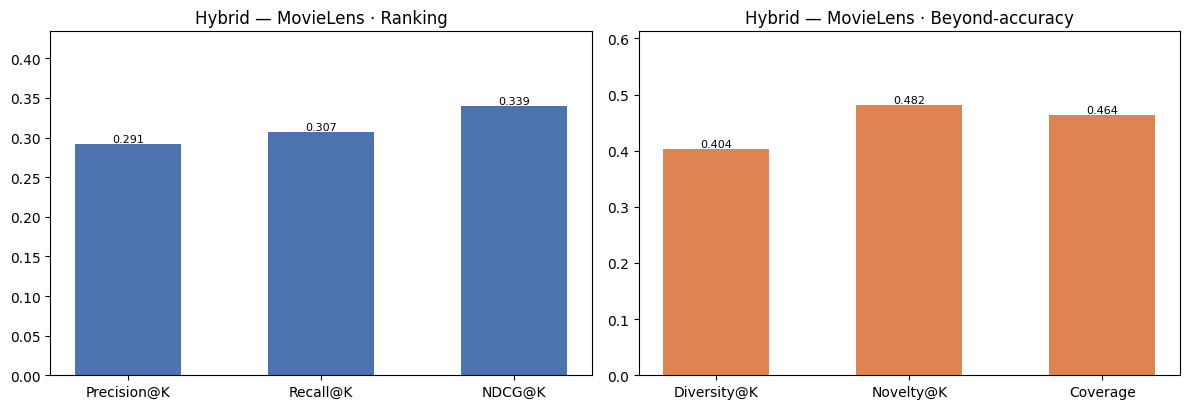


Evaluando en Survey (86 folds, ≥15 ratings)...
  completado en 0s


### Hybrid — Survey (K=10)

╒═════════════╤═════════╕
│ Métrica     │   Valor │
╞═════════════╪═════════╡
│ hr          │   0.791 │
├─────────────┼─────────┤
│ ndcg        │   0.406 │
├─────────────┼─────────┤
│ n_evaluated │  86     │
├─────────────┼─────────┤
│ n_skipped   │   0     │
╘═════════════╧═════════╛


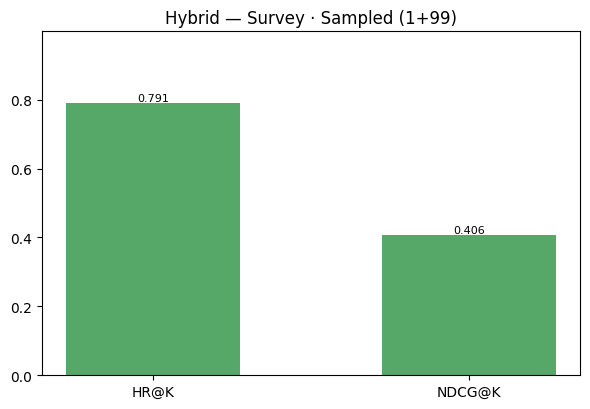

In [70]:
# Re-fit lightweight models on full train; CF/PMLP keep loaded weights
pop_model.fit(train)
cb_model.fit(train)
cf_model._seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    cf_model._seen.setdefault(int(uid), set()).add(int(mid))
pmlp_model._user_seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    pmlp_model._user_seen.setdefault(int(uid), set()).add(int(mid))

hybrid_final = HybridRankFusionRecommender(model_list, best_weights)
hybrid_final._user_seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    hybrid_final._user_seen.setdefault(int(uid), set()).add(int(mid))

# ── Benchmark (full-catalog) ──
class _NoFitWrapper:
    def __init__(self, model):
        self._m = model
    def fit(self, *a, **kw): pass
    def recommend(self, *a, **kw): return self._m.recommend(*a, **kw)
    def score_all(self, *a, **kw): return self._m.score_all(*a, **kw)

print('Evaluando en Benchmark (full-catalog)...')
t0 = time.time()
bench_results = nu.evaluate_movielens(
    _NoFitWrapper(hybrid_final), train, test, K, cosine_sim, popularity, N_ITEMS,
)
print(f'  completado en {time.time()-t0:.0f}s')
display(Markdown(f'### Hybrid — Benchmark (K={K})'))
nu.print_metrics(bench_results)
nu.plot_movielens_metrics(bench_results, title_prefix='Hybrid — ')

# ── Survey (sampled LOO) ──
print(f'\nEvaluando en Survey ({len(sv_folds)} folds, ≥{MIN_RATINGS} ratings)...')
t0 = time.time()

def _hybrid_factory():
    h = HybridRankFusionRecommender(model_list, best_weights)
    return h

survey_results = nu.evaluate_survey(
    model_factory=_hybrid_factory,
    folds=sv_folds,
    k=K,
    n_items=N_ITEMS,
)
print(f'  completado en {time.time()-t0:.0f}s')
display(Markdown(f'### Hybrid — Survey (K={K})'))
nu.print_metrics(survey_results)
nu.plot_survey_metrics(survey_results, title_prefix='Hybrid — ')


## 7. Ejemplos de recomendaciones

Se muestran las recomendaciones del modelo híbrido para los **mismos 3 usuarios** que se usaron en los notebooks 1-3, para poder comparar directamente cómo cambian las recomendaciones al combinar los 4 modelos.

In [71]:
movies_df = pd.read_csv(cfg.MOVIES_PATH)
lookup = {int(r.movie_id): (r.title, str(r.release_date)[:4] if pd.notna(getattr(r, 'release_date', None)) else '—')
          for r in movies_df.itertuples(index=False)}

rng_ex = np.random.default_rng(42)
sample_users = rng_ex.choice(test['user_id'].unique(), size=3, replace=False).tolist()
for uid in sample_users:
    display(Markdown(f'### Usuario {uid}'))
    recs = hybrid_final.recommend(int(uid), n=K)
    rows = []
    for rank, mid in enumerate(recs, 1):
        title, year = lookup.get(int(mid), (f'<idx {mid}>', '—'))
        rows.append([rank, title, year])
    print(tabulate(rows, headers=['#', 'Título', 'Año'], tablefmt='fancy_grid'))


### Usuario 3927

╒═════╤══════════════════════════╤═══════╕
│   # │ Título                   │   Año │
╞═════╪══════════════════════════╪═══════╡
│   1 │ Easy A                   │  2010 │
├─────┼──────────────────────────┼───────┤
│   2 │ Hitch                    │  2005 │
├─────┼──────────────────────────┼───────┤
│   3 │ The Bucket List          │  2007 │
├─────┼──────────────────────────┼───────┤
│   4 │ Mean Girls               │  2004 │
├─────┼──────────────────────────┼───────┤
│   5 │ Step Brothers            │  2008 │
├─────┼──────────────────────────┼───────┤
│   6 │ Yes Man                  │  2008 │
├─────┼──────────────────────────┼───────┤
│   7 │ Up                       │  2009 │
├─────┼──────────────────────────┼───────┤
│   8 │ Despicable Me            │  2010 │
├─────┼──────────────────────────┼───────┤
│   9 │ I Love You, Man          │  2009 │
├─────┼──────────────────────────┼───────┤
│  10 │ How to Train Your Dragon │  2010 │
╘═════╧══════════════════════════╧═══════╛


### Usuario 535

╒═════╤═══════════════════╤═══════╕
│   # │ Título            │   Año │
╞═════╪═══════════════════╪═══════╡
│   1 │ The Iron Giant    │  1999 │
├─────┼───────────────────┼───────┤
│   2 │ The Mask of Zorro │  1998 │
├─────┼───────────────────┼───────┤
│   3 │ The Fifth Element │  1997 │
├─────┼───────────────────┼───────┤
│   4 │ Blade             │  1998 │
├─────┼───────────────────┼───────┤
│   5 │ Sleepy Hollow     │  1999 │
├─────┼───────────────────┼───────┤
│   6 │ Anastasia         │  1997 │
├─────┼───────────────────┼───────┤
│   7 │ Rush Hour         │  1998 │
├─────┼───────────────────┼───────┤
│   8 │ Hercules          │  1997 │
├─────┼───────────────────┼───────┤
│   9 │ Braveheart        │  1995 │
├─────┼───────────────────┼───────┤
│  10 │ The X-Files       │  1998 │
╘═════╧═══════════════════╧═══════╛


### Usuario 4641

╒═════╤══════════════════════════════════════╤═══════╕
│   # │ Título                               │   Año │
╞═════╪══════════════════════════════════════╪═══════╡
│   1 │ Star Trek: First Contact             │  1996 │
├─────┼──────────────────────────────────────┼───────┤
│   2 │ Ghost in the Shell                   │  1995 │
├─────┼──────────────────────────────────────┼───────┤
│   3 │ Robot Chicken: Star Wars Episode II  │  2008 │
├─────┼──────────────────────────────────────┼───────┤
│   4 │ Avengers: Infinity War               │  2018 │
├─────┼──────────────────────────────────────┼───────┤
│   5 │ The Iron Giant                       │  1999 │
├─────┼──────────────────────────────────────┼───────┤
│   6 │ Black Hawk Down                      │  2001 │
├─────┼──────────────────────────────────────┼───────┤
│   7 │ Robot Chicken: Star Wars Episode III │  2010 │
├─────┼──────────────────────────────────────┼───────┤
│   8 │ X2                                   │  2003 │
├─────┼───

## 6. Persistencia

Se guardan los resultados finales y los pesos óptimos del modelo híbrido.

In [ ]:
model_names = list(models.keys())

summary = {
    'weights': {name: float(w) for name, w in zip(model_names, best_weights)},
    'eval_benchmark': bench_results,
    'eval_survey': survey_results,
}

meta = {
    'model': 'HybridWeightedScoreFusion',
    'weights': {name: float(w) for name, w in zip(model_names, best_weights)},
    'sub_models': model_names,
}
SAVED_DIR.mkdir(parents=True, exist_ok=True)
with open(SAVED_DIR / 'hybrid_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

Resultados → /Users/dariozsh/Downloads/Final RS/ml/results/hybrid_summary.json
Metadatos → ../models/saved/hybrid_meta.json
